# 04: Threshold Tuning

The default 0.5 cutoff for "risky vs. not" is arbitrary. It isn't grounded
in what a wrong decision actually costs. XGBoost's minority-class precision
at 0.5 is a weak ~0.21, driven by `scale_pos_weight` pushing the model to
flag more people as risky at the default threshold. This notebook searches
for a better cutoff.

Only XGBoost is tuned here. It's the stronger model (higher AUC/KS) and
the one carried forward to the SHAP/LLM explainer.

**Important rule followed throughout:** thresholds are chosen using a
validation split carved out of `X_train` only. `X_test` is never touched
until the very final check, to keep it genuinely unseen.

**Output:** the chosen threshold saved to `../models/threshold.json`,
consumed by the eventual FastAPI backend.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

## Load processed data and the trained XGBoost model

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0).iloc[:, 0]
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0).iloc[:, 0]

xgb_model = joblib.load('../models/xgb_model.joblib')

## Validation carve-out

`xgb_model` was already fit on all of `X_train`, so using part of it as
"validation" now would be slightly optimistic (the model has already seen
those exact rows). A temporary clone, refit on a subset, gives a genuinely
unseen validation slice to explore threshold candidates on.

In [3]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

xgb_val = clone(xgb_model)
xgb_val.fit(X_tr, y_tr)

y_prob_val = xgb_val.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.05, 0.96, 0.01)

## Visualizing the tradeoff: TPR vs. FPR by threshold

The gap between these two curves at any given threshold is exactly what
the KS statistic measures. The point of widest separation is the
Youden's J-optimal cutoff.

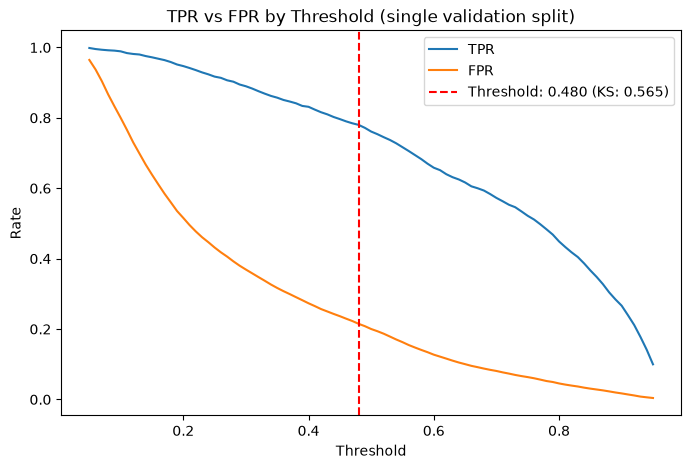

Best threshold (single split): 0.480, KS = 0.565


In [4]:
fn_rates = []
fp_rates = []
for t in thresholds:
    y_pred_t = (y_prob_val >= t).astype(int)
    fn = ((y_pred_t == 0) & (y_val == 1)).sum()
    tp = ((y_pred_t == 1) & (y_val == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val == 0)).sum()
    tn = ((y_pred_t == 0) & (y_val == 0)).sum()
    fn_rates.append(fn / (fn + tp))
    fp_rates.append(fp / (fp + tn))

tpr_rates = 1 - np.array(fn_rates)
fpr_rates = np.array(fp_rates)
ks_values = tpr_rates - fpr_rates

best_idx = np.argmax(ks_values)
best_threshold_j = thresholds[best_idx]
ks_max = ks_values[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, tpr_rates, label='TPR')
plt.plot(thresholds, fpr_rates, label='FPR')
plt.axvline(x=best_threshold_j, color='r', linestyle='--',
            label=f'Threshold: {best_threshold_j:.3f} (KS: {ks_max:.3f})')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.title('TPR vs FPR by Threshold (single validation split)')
plt.legend()
plt.show()

print(f"Best threshold (single split): {best_threshold_j:.3f}, KS = {ks_max:.3f}")

## Stability check: is the single-split threshold reliable?

A threshold computed from one particular validation split is a single
point estimate with some variance. Repeating the search across 5
stratified folds shows whether ~this same value keeps showing up, or
whether it's sensitive to which rows happened to land in validation.

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_thresholds = []

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    xgb_fold = clone(xgb_model)
    xgb_fold.fit(X_tr_fold, y_tr_fold)
    y_prob_fold = xgb_fold.predict_proba(X_val_fold)[:, 1]

    ks_vals = []
    for t in thresholds:
        y_pred_t = (y_prob_fold >= t).astype(int)
        tp = ((y_pred_t == 1) & (y_val_fold == 1)).sum()
        fn = ((y_pred_t == 0) & (y_val_fold == 1)).sum()
        fp = ((y_pred_t == 1) & (y_val_fold == 0)).sum()
        tn = ((y_pred_t == 0) & (y_val_fold == 0)).sum()
        ks_vals.append(tp / (tp + fn) - fp / (fp + tn))

    best_fold_idx = np.argmax(ks_vals)
    fold_thresholds.append(thresholds[best_fold_idx])
    print(f"Fold {fold_idx + 1}: best threshold = {thresholds[best_fold_idx]:.3f}, "
          f"KS = {ks_vals[best_fold_idx]:.3f}")

mean_threshold = float(np.mean(fold_thresholds))
std_threshold = float(np.std(fold_thresholds))
print(f"\nMean threshold: {mean_threshold:.3f}  +/-  {std_threshold:.3f}")

Fold 1: best threshold = 0.490, KS = 0.587


Fold 2: best threshold = 0.490, KS = 0.568


Fold 3: best threshold = 0.490, KS = 0.569


Fold 4: best threshold = 0.520, KS = 0.567


Fold 5: best threshold = 0.460, KS = 0.579

Mean threshold: 0.490  +/-  0.019


## Final check: apply the chosen threshold to the real, untouched test set

This is the one-time use of `X_test` for this task, scored with the
original `xgb_model` (trained on all of `X_train`), never the temporary
clones used above.

In [6]:
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]
y_pred_test_tuned = (y_prob_test >= mean_threshold).astype(int)

print(f"Threshold used: {mean_threshold:.3f}")
print(classification_report(y_test, y_pred_test_tuned))

Threshold used: 0.490
              precision    recall  f1-score   support

           0       0.98      0.79      0.87     27995
           1       0.21      0.79      0.33      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.60     30000
weighted avg       0.93      0.79      0.84     30000



## Save the chosen threshold

In [7]:
with open('../models/threshold.json', 'w') as f:
    json.dump({
        "model": "xgb_model",
        "threshold": mean_threshold,
        "threshold_std_across_folds": std_threshold,
        "method": "5-fold CV, KS statistic / Youden's J (TPR - FPR) maximization",
        "note": "Treats false negatives and false positives as equally costly (1:1)."
    }, f, indent=2)

print("Saved threshold to ../models/threshold.json")

Saved threshold to ../models/threshold.json
